<a href="https://colab.research.google.com/github/Ammarah171/NLP/blob/main/CSE440_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Scikit-learn for ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# TensorFlow/Keras for Neural Networks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Embedding, SimpleRNN,
                                     GRU, LSTM, Bidirectional, GlobalMaxPooling1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Install gensim if not already installed
!pip install gensim

# Word2Vec for Skip-gram embeddings
from gensim.models import Word2Vec

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Display settings
pd.set_option('display.max_colwidth', 200)
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.20.0


In [4]:
# Load the datasets
train_df = pd.read_csv('Trainfile.csv', on_bad_lines='skip', engine='python')
test_df = pd.read_csv('Testfile.csv', on_bad_lines='skip', engine='python')

# Display basic information
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nTraining set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")
print(f"\nColumn names: {train_df.columns.tolist()}")
print(f"\nData types:\n{train_df.dtypes}")

# Display first few rows
print("\n" + "=" * 60)
print("SAMPLE DATA (First 3 rows)")
print("=" * 60)
train_df.head(3)

DATASET OVERVIEW

Training set shape: (93333, 2)
Testing set shape: (59999, 2)

Column names: ['QA Text', 'Class']

Data types:
QA Text    object
Class      object
dtype: object

SAMPLE DATA (First 3 rows)


,QA Text,Class
0,<html> Question Title:\n <br> Would thoughts go through your head when you see a major hottie walking down the street?\n <br> <br> <br><br><br> Question Content:\n <br> \n <br> <br>Best Answer:\n ...,Society & Culture
1,"<html> Question Title:\n <br> How is ""not being a verified PayPal user"" going to affect my account use?\n <br> <br> <br><br><br> Question Content:\n <br> I have a turkish paypal acount. I don't wa...",Business & Finance
2,<html> Question Title:\n <br> thunder from down under?\n <br> <br> <br><br><br> Question Content:\n <br> \n <br> <br>Best Answer:\n <br> buy the tickets and go!! </html>,Entertainment & Music


In [5]:
# Check for missing values
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
print("\nTraining set missing values:")
print(train_df.isnull().sum())
print(f"\nTotal missing in training: {train_df.isnull().sum().sum()}")

print("\nTesting set missing values:")
print(test_df.isnull().sum())
print(f"\nTotal missing in testing: {test_df.isnull().sum().sum()}")

MISSING VALUES ANALYSIS

Training set missing values:
QA Text    0
Class      0
dtype: int64

Total missing in training: 0

Testing set missing values:
QA Text    0
Class      0
dtype: int64

Total missing in testing: 0


In [6]:
# Class distribution analysis
print("=" * 60)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 60)

# Define class labels for better visualization (kept for potential future use or reference)
class_labels = {
    1: 'Society & Culture',
    2: 'Science & Mathematics',
    3: 'Health',
    4: 'Education & Reference',
    5: 'Computers & Internet',
    6: 'Sports',
    7: 'Business & Finance',
    8: 'Entertainment & Music',
    9: 'Family & Relationships',
    10: 'Politics & Government'
}

# Training set class distribution
print("\nTraining set class distribution:")
train_class_counts = train_df['Class'].value_counts().sort_index()
for cls, count in train_class_counts.items():
    print(f"  Class {cls}: {count} ({count/len(train_df)*100:.2f}%)")

# Testing set class distribution
print("\nTesting set class distribution:")
test_class_counts = test_df['Class'].value_counts().sort_index()
for cls, count in test_class_counts.items():
    print(f"  Class {cls}: {count} ({count/len(test_df)*100:.2f}%)")

CLASS DISTRIBUTION ANALYSIS

Training set class distribution:
  Class Business & Finance: 9383 (10.05%)
  Class Computers & Internet: 9440 (10.11%)
  Class Education & Reference: 9367 (10.04%)
  Class Entertainment & Music: 9366 (10.04%)
  Class Family & Relationships: 9481 (10.16%)
  Class Health: 9243 (9.90%)
  Class Politics & Government: 9308 (9.97%)
  Class Science & Mathematics: 9440 (10.11%)
  Class Society & Culture: 9204 (9.86%)
  Class Sports: 9101 (9.75%)

Testing set class distribution:
  Class Business & Finance: 6000 (10.00%)
  Class Computers & Internet: 6000 (10.00%)
  Class Education & Reference: 6000 (10.00%)
  Class Entertainment & Music: 6000 (10.00%)
  Class Family & Relationships: 5999 (10.00%)
  Class Health: 6000 (10.00%)
  Class Politics & Government: 6000 (10.00%)
  Class Science & Mathematics: 6000 (10.00%)
  Class Society & Culture: 6000 (10.00%)
  Class Sports: 6000 (10.00%)


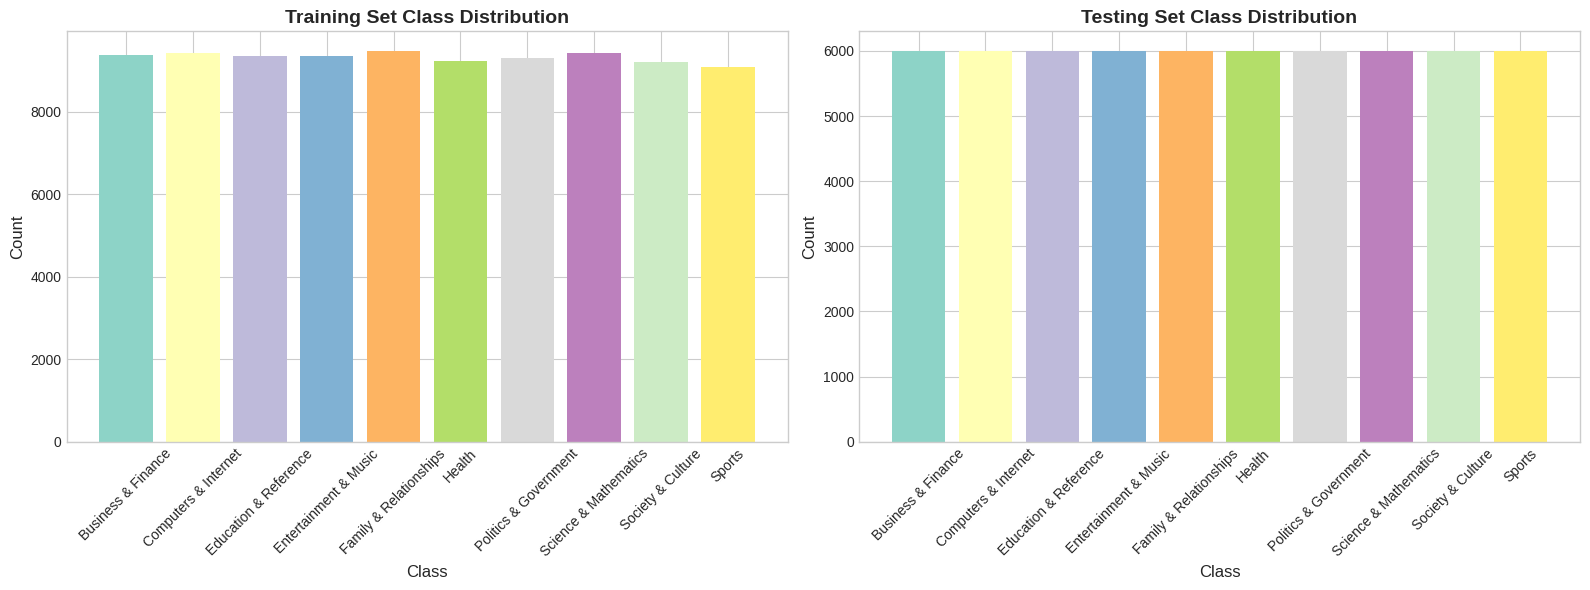


 OBSERVATION: The dataset appears to be balanced with equal distribution across all 10 classes.


In [7]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
colors = plt.cm.Set3(np.linspace(0, 1, 10))
axes[0].bar(train_class_counts.index,
            train_class_counts.values, color=colors)
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Testing set
axes[1].bar(test_class_counts.index,
            test_class_counts.values, color=colors)
axes[1].set_title('Testing Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n OBSERVATION: The dataset appears to be balanced with equal distribution across all 10 classes.")

TEXT LENGTH ANALYSIS

Text Length Statistics (characters):
count    93333.000000
mean       633.581627
std        575.803422
min        127.000000
25%        290.000000
50%        454.000000
75%        752.000000
max       5964.000000
Name: text_length, dtype: float64

Word Count Statistics:
count    93333.000000
mean       106.445309
std         98.570510
min         16.000000
25%         46.000000
50%         76.000000
75%        129.000000
max       1103.000000
Name: word_count, dtype: float64


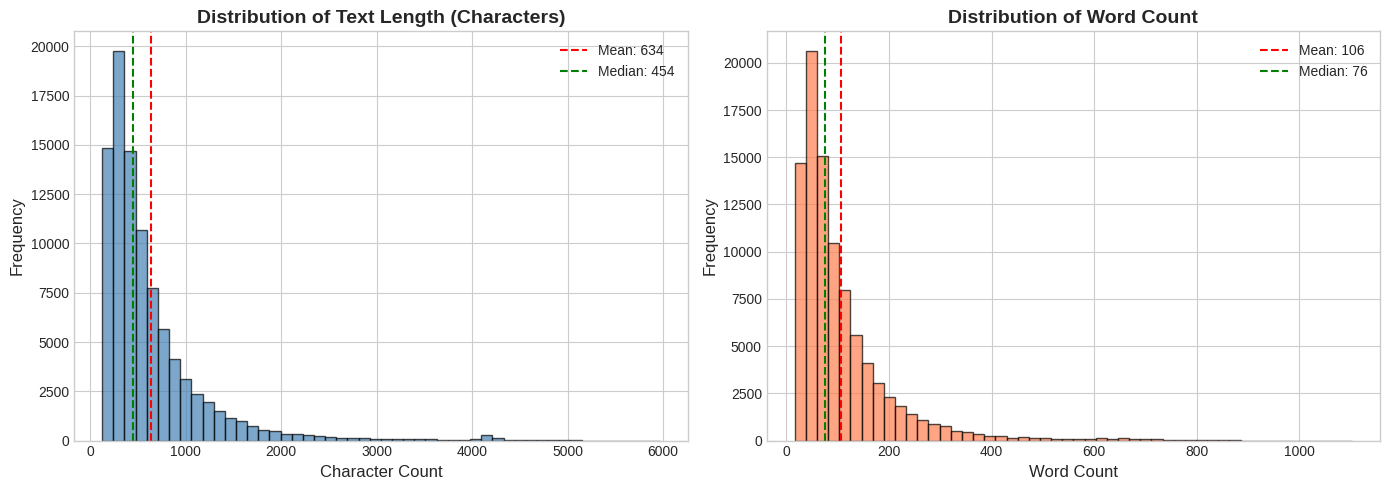

In [8]:
# Text length analysis
print("=" * 60)
print("TEXT LENGTH ANALYSIS")
print("=" * 60)

# Calculate text lengths
train_df['text_length'] = train_df['QA Text'].apply(len)
train_df['word_count'] = train_df['QA Text'].apply(lambda x: len(str(x).split()))

print("\nText Length Statistics (characters):")
print(train_df['text_length'].describe())

print("\nWord Count Statistics:")
print(train_df['word_count'].describe())

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution
axes[0].hist(train_df['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(train_df['text_length'].mean(), color='red', linestyle='--', label=f'Mean: {train_df["text_length"].mean():.0f}')
axes[0].axvline(train_df['text_length'].median(), color='green', linestyle='--', label=f'Median: {train_df["text_length"].median():.0f}')
axes[0].set_title('Distribution of Text Length (Characters)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Character Count', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

# Word count distribution
axes[1].hist(train_df['word_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(train_df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {train_df["word_count"].mean():.0f}')
axes[1].axvline(train_df['word_count'].median(), color='green', linestyle='--', label=f'Median: {train_df["word_count"].median():.0f}')
axes[1].set_title('Distribution of Word Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Analyze HTML structure in text
print("=" * 60)
print("HTML STRUCTURE ANALYSIS")
print("=" * 60)

# Sample text to understand structure
sample_text = train_df['QA Text'].iloc[0]
print("\nSample raw text:")
print("-" * 60)
print(sample_text[:1000])
print("-" * 60)

# Check for HTML tags
html_patterns = {
    '<html>': train_df['QA Text'].str.contains('<html>', case=False).sum(),
    '</html>': train_df['QA Text'].str.contains('</html>', case=False).sum(),
    '<form>': train_df['QA Text'].str.contains('<form>', case=False).sum(),
    '</form>': train_df['QA Text'].str.contains('</form>', case=False).sum(),
    '<br>': train_df['QA Text'].str.contains('<br>', case=False).sum(),
    'Question Title:': train_df['QA Text'].str.contains('Question Title:', case=False).sum(),
    'Question Content:': train_df['QA Text'].str.contains('Question Content:', case=False).sum(),
    'Best Answer:': train_df['QA Text'].str.contains('Best Answer:', case=False).sum(),
}

print("\nHTML/Structure Pattern Counts:")
for pattern, count in html_patterns.items():
    print(f"  '{pattern}': {count} occurrences ({count/len(train_df)*100:.2f}%)")

HTML STRUCTURE ANALYSIS

Sample raw text:
------------------------------------------------------------
<html> Question Title:
 <br> Would thoughts go through your head when you see a major hottie walking down the street?
 <br> <br> <br><br><br> Question Content:
 <br> 
 <br> <br>Best Answer:
 <br> Well... thoughts won't go through your head but you might experience some changes down there, if you know what I mean hehehe. </html>
------------------------------------------------------------

HTML/Structure Pattern Counts:
  '<html>': 93333 occurrences (100.00%)
  '</html>': 93333 occurrences (100.00%)
  '<form>': 1 occurrences (0.00%)
  '</form>': 3 occurrences (0.00%)
  '<br>': 93333 occurrences (100.00%)
  'Question Title:': 93333 occurrences (100.00%)
  'Question Content:': 93333 occurrences (100.00%)
  'Best Answer:': 93333 occurrences (100.00%)


**Preprocessing**

Initialize preprocessing components


In [10]:
# Initialize preprocessing components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def clean_text(text, use_lemmatization=True, remove_stopwords=True):
    """
    Comprehensive text cleaning function.

    Steps:
    1. Remove HTML tags
    2. Remove structural markers
    3. Lowercase
    4. Remove special characters and numbers
    5. Tokenize
    6. Remove stopwords (optional)
    7. Apply lemmatization or stemming

    Args:
        text: Raw input text
        use_lemmatization: If True, use lemmatization; else use stemming
        remove_stopwords: If True, remove English stopwords

    Returns:
        Cleaned text string
    """
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Remove HTML tags
    text = re.sub(r'<html>|</html>|<form>|</form>|<br>', ' ', text, flags=re.IGNORECASE)

    # Remove structural markers
    text = re.sub(r'Question Title:|Question Content:|Best Answer:', ' ', text, flags=re.IGNORECASE)

    # Convert to lowercase
    text = text.lower()

    #
    text = re.sub(r'http\S+|www\S+', ' ', text)

    #
    text = re.sub(r'\S+@\S+', ' ', text)

    #
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords if specified
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]

    # Apply lemmatization or stemming
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
    else:
        tokens = [stemmer.stem(token) for token in tokens]

    # Remove very short tokens
    tokens = [token for token in tokens if len(token) > 2]

    return ' '.join(tokens)

# Test the cleaning function
sample_raw = train_df['QA Text'].iloc[0]
sample_cleaned = clean_text(sample_raw)

print("=" * 60)
print("TEXT CLEANING DEMONSTRATION")
print("=" * 60)
print("\nOriginal text (first 500 chars):")
print("-" * 60)
print(sample_raw[:500])
print("-" * 60)
print("\nCleaned text:")
print("-" * 60)
print(sample_cleaned[:500])
print("-" * 60)

TEXT CLEANING DEMONSTRATION

Original text (first 500 chars):
------------------------------------------------------------
<html> Question Title:
 <br> Would thoughts go through your head when you see a major hottie walking down the street?
 <br> <br> <br><br><br> Question Content:
 <br> 
 <br> <br>Best Answer:
 <br> Well... thoughts won't go through your head but you might experience some changes down there, if you know what I mean hehehe. </html>
------------------------------------------------------------

Cleaned text:
------------------------------------------------------------
would thought head see major hottie walking street well thought head might experience change know mean hehehe
------------------------------------------------------------


In [11]:
# Apply preprocessing to entire dataset
print("=" * 60)
print("APPLYING PREPROCESSING TO DATASET")
print("=" * 60)
print("\nThis may take a few minutes...")

from tqdm import tqdm
tqdm.pandas()

# Apply cleaning to training data
print("\nProcessing training data...")
train_df['cleaned_text'] = train_df['QA Text'].progress_apply(clean_text)

# Apply cleaning to testing data
print("\nProcessing testing data...")
test_df['cleaned_text'] = test_df['QA Text'].progress_apply(clean_text)

print("\n Preprocessing complete!")

# Show statistics after cleaning
print("\n" + "=" * 60)
print("POST-PREPROCESSING STATISTICS")
print("=" * 60)

train_df['cleaned_word_count'] = train_df['cleaned_text'].apply(lambda x: len(x.split()))
test_df['cleaned_word_count'] = test_df['cleaned_text'].apply(lambda x: len(x.split()))

print("\nTraining set - Cleaned word count statistics:")
print(train_df['cleaned_word_count'].describe())

print("\nTesting set - Cleaned word count statistics:")
print(test_df['cleaned_word_count'].describe())

APPLYING PREPROCESSING TO DATASET

This may take a few minutes...

Processing training data...


100%|██████████| 93333/93333 [01:21<00:00, 1150.97it/s]



Processing testing data...


100%|██████████| 59999/59999 [00:45<00:00, 1318.56it/s]



 Preprocessing complete!

POST-PREPROCESSING STATISTICS

Training set - Cleaned word count statistics:
count    93333.000000
mean        44.793246
std         50.291097
min          0.000000
25%         15.000000
50%         29.000000
75%         55.000000
max        507.000000
Name: cleaned_word_count, dtype: float64

Testing set - Cleaned word count statistics:
count    59999.00000
mean        44.98745
std         50.66582
min          0.00000
25%         15.00000
50%         29.00000
75%         55.00000
max        500.00000
Name: cleaned_word_count, dtype: float64


WORD FREQUENCY ANALYSIS (After Preprocessing)

Top 20 Most Common Words:
  like: 31298
  get: 31209
  one: 28657
  would: 27255
  know: 27167
  think: 20886
  time: 20727
  people: 20626
  want: 19668
  good: 17810
  need: 17647
  make: 16830
  help: 16756
  year: 14756
  thing: 13487
  way: 13458
  also: 13254
  say: 12975
  really: 12562
  find: 12168


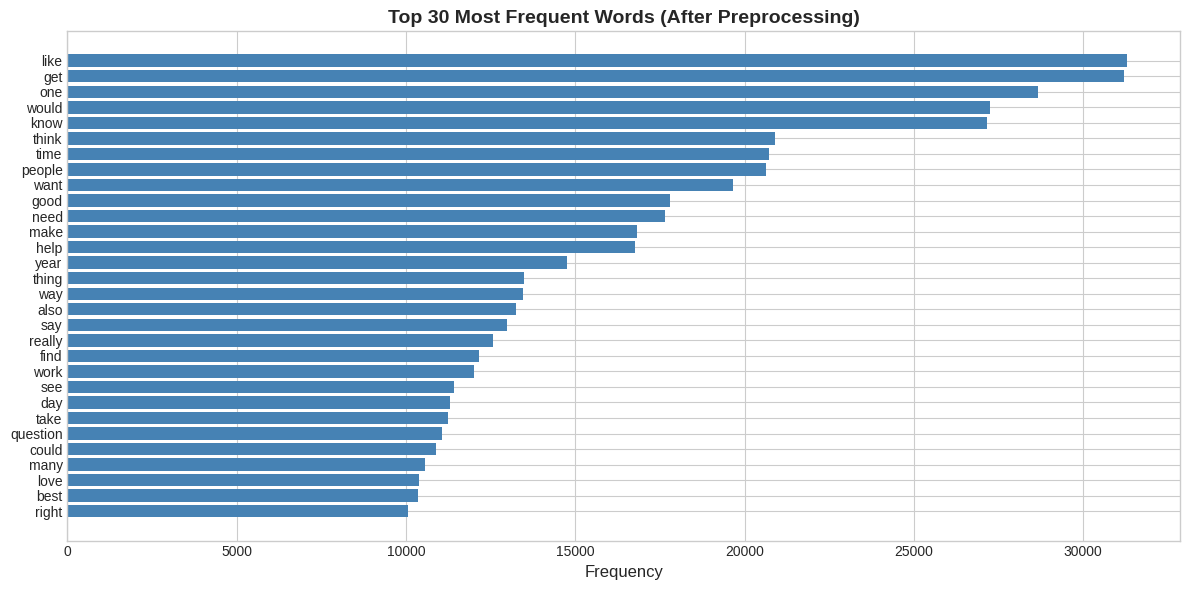


📊 Total unique words in vocabulary: 137,402


In [12]:
# Word frequency analysis on cleaned data
print("=" * 60)
print("WORD FREQUENCY ANALYSIS (After Preprocessing)")
print("=" * 60)

# Get all words from cleaned training data
all_words = ' '.join(train_df['cleaned_text'].tolist()).split()
word_freq = Counter(all_words)

# Most common words
print("\nTop 20 Most Common Words:")
for word, count in word_freq.most_common(20):
    print(f"  {word}: {count}")

# Visualize top words
fig, ax = plt.subplots(figsize=(12, 6))
top_words = word_freq.most_common(30)
words, counts = zip(*top_words)
ax.barh(range(len(words)), counts, color='steelblue')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 30 Most Frequent Words (After Preprocessing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Total unique words in vocabulary: {len(word_freq):,}")

Prepare features and labels

In [13]:
# Prepare features and labels

# Create a mapping from class names to 0-indexed integers
# class_labels dictionary is {1: 'Society & Culture', ..., 10: 'Politics & Government'}
# We want to map 'Society & Culture' to 0, 'Science & Mathematics' to 1, etc.
label_to_int = {label: i - 1 for i, label in class_labels.items()}

X_train_full = train_df['cleaned_text'].values
y_train_full = train_df['Class'].map(label_to_int).values  # Convert to 0-indexed

X_test = test_df['cleaned_text'].values
y_test = test_df['Class'].map(label_to_int).values  # Convert to 0-indexed

# Create train/validation split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("=" * 60)
print("DATA SPLIT SUMMARY")
print("=" * 60)
print(f"\nTraining set size: {len(X_train):,}")
print(f"Validation set size: {len(X_val):,}")
print(f"Testing set size: {len(X_test):,}")
print(f"\nNumber of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

DATA SPLIT SUMMARY

Training set size: 74,666
Validation set size: 18,667
Testing set size: 59,999

Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]



## Section 5: TF-IDF Vectorization

In [14]:
# TF-IDF Vectorization
print("=" * 60)
print("TF-IDF VECTORIZATION")
print("=" * 60)

# Hyperparameters for TF-IDF (to be tuned)
# Decision: Using max_features=10000 to balance vocabulary coverage and computational efficiency
# Decision: Using ngram_range=(1,2) to capture both unigrams and bigrams for better context
# Decision: Using min_df=2 to remove very rare terms that may be noise

tfidf_params = {
    'max_features': 10000,
    'ngram_range': (1, 2),
    'min_df': 2,
    'max_df': 0.95,
    'sublinear_tf': True
}

print("\nTF-IDF Hyperparameters:")
for param, value in tfidf_params.items():
    print(f"  {param}: {value}")

# Initialize and fit TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(**tfidf_params)

# Fit on training data and transform
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF Matrix Shapes:")
print(f"  Training: {X_train_tfidf.shape}")
print(f"  Validation: {X_val_tfidf.shape}")
print(f"  Testing: {X_test_tfidf.shape}")
print(f"\nVocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")

TF-IDF VECTORIZATION

TF-IDF Hyperparameters:
  max_features: 10000
  ngram_range: (1, 2)
  min_df: 2
  max_df: 0.95
  sublinear_tf: True

TF-IDF Matrix Shapes:
  Training: (74666, 10000)
  Validation: (18667, 10000)
  Testing: (59999, 10000)

Vocabulary size: 10,000


## Section 6: Model Training - Experiment 1: Logistic Regression with TF-IDF
Train a Logistic Regression model using TF-IDF features.

In [15]:
# Helper function for model evaluation
def evaluate_model(y_true, y_pred, model_name, class_labels_dict):
    """
    Comprehensive model evaluation function.

    Args:
        y_true: True labels
        y_pred: Predicted labels
        model_name: Name of the model for display
        class_labels_dict: Dictionary mapping class indices to names

    Returns:
        Dictionary with evaluation metrics
    """
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')

    print("=" * 70)
    print(f"EVALUATION RESULTS: {model_name}")
    print("=" * 70)
    print(f"\n Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f" F1-Score (Macro): {f1_macro:.4f}")

    # Classification Report
    print("\n" + "-" * 70)
    print("Classification Report:")
    print("-" * 70)
    target_names = [class_labels_dict[i] for i in range(10)]
    print(classification_report(y_true, y_pred, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=45)
    ax.set_title(f'Confusion Matrix: {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'model': model_name,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'confusion_matrix': cm
    }

# Store results for comparison
all_results = []
print(" Evaluation function defined!")

 Evaluation function defined!


In [16]:
# Experiment 1: Logistic Regression with TF-IDF
print("=" * 60)
print("EXPERIMENT 1: LOGISTIC REGRESSION WITH TF-IDF")
print("=" * 60)



lr_params = {
    'C': 1.0,
    'max_iter': 1000,
    'solver': 'lbfgs',
    'multi_class': 'multinomial',
    'random_state': 42,
    'n_jobs': -1
}

print("\nLogistic Regression Hyperparameters:")
for param, value in lr_params.items():
    print(f"  {param}: {value}")

# Train the modelnt("\nTraining Logistic Regression...")
lr_model = LogisticRegression(**lr_params)
lr_model.fit(X_train_tfidf, y_train)
print(" Training complete!")

# Validate
print("\nValidating on validation set...")
y_val_pred_lr = lr_model.predict(X_val_tfidf)
val_accuracy = accuracy_score(y_val, y_val_pred_lr)
val_f1 = f1_score(y_val, y_val_pred_lr, average='macro')
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation F1-Score: {val_f1:.4f}")

EXPERIMENT 1: LOGISTIC REGRESSION WITH TF-IDF

Logistic Regression Hyperparameters:
  C: 1.0
  max_iter: 1000
  solver: lbfgs
  multi_class: multinomial
  random_state: 42
  n_jobs: -1
 Training complete!

Validating on validation set...
Validation Accuracy: 0.6792
Validation F1-Score: 0.6770



FINAL EVALUATION ON TEST SET
EVALUATION RESULTS: Logistic Regression (TF-IDF)

 Accuracy: 0.6825 (68.25%)
 F1-Score (Macro): 0.6803

----------------------------------------------------------------------
Classification Report:
----------------------------------------------------------------------
                        precision    recall  f1-score   support

     Society & Culture       0.58      0.53      0.56      6000
 Science & Mathematics       0.67      0.72      0.70      6000
                Health       0.74      0.76      0.75      6000
 Education & Reference       0.53      0.50      0.51      6000
  Computers & Internet       0.80      0.84      0.82      6000
                Sports       0.85      0.82      0.84      6000
    Business & Finance       0.55      0.49      0.52      6000
 Entertainment & Music       0.64      0.67      0.65      6000
Family & Relationships       0.68      0.75      0.71      5999
 Politics & Government       0.75      0.74      0.74      6

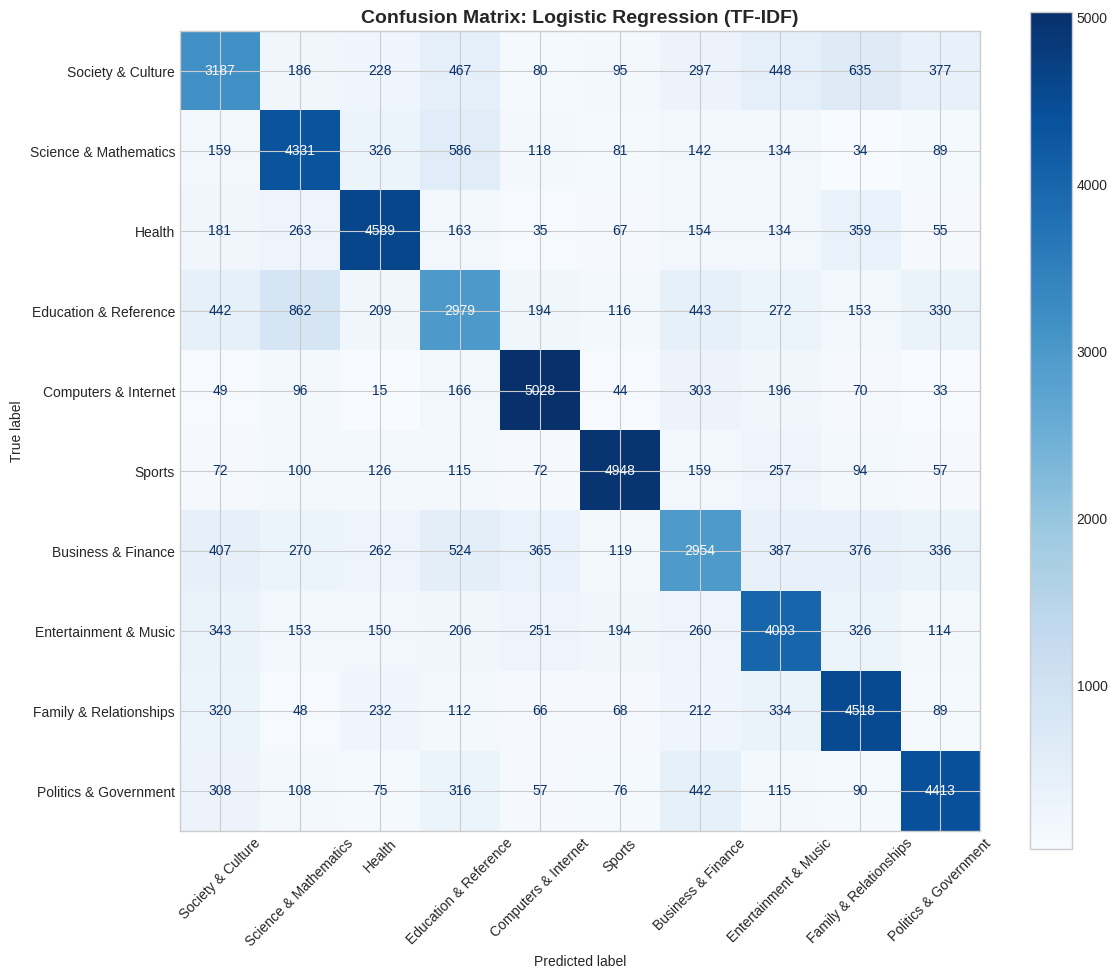

In [17]:
# Create a mapping from 0-indexed integers back to class names for evaluation display
# The original 'class_labels' dictionary uses 1-indexed keys (1 to 10).
# 'y_test' and 'y_test_pred_lr' are 0-indexed (0 to 9).
# So we need a dictionary like {0: 'Society & Culture', 1: 'Science & Mathematics', ...}
int_to_class_name = {i - 1: class_labels[i] for i in range(1, len(class_labels) + 1)}

# Evaluate on test set
print(
    "\n" + "=" * 60
)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)

y_test_pred_lr = lr_model.predict(X_test_tfidf)
lr_results = evaluate_model(
    y_test, y_test_pred_lr, "Logistic Regression (TF-IDF)", int_to_class_name
)
all_results.append(lr_results)

## Section 7: Experiment 2 - Deep Neural Network with TF-IDF
Train a DNN model using TF-IDF features.

## Section 8: Skip-gram (Word2Vec) Embeddings
Prepare word embeddings using Word2Vec Skip-gram for neural network models.

In [18]:
# Prepare tokenized sentences for Word2Vec training
print("=" * 60)
print("WORD2VEC SKIP-GRAM EMBEDDING TRAINING")
print("=" * 60)

# Tokenize sentences
tokenized_train = [text.split() for text in X_train]
tokenized_val = [text.split() for text in X_val]
tokenized_test = [text.split() for text in X_test]

# Word2Vec Skip-gram hyperparameters and justification:
# - vector_size: 100 - Good balance between representation power and training time
# - window: 5 - Context window size
# - min_count: 2 - Minimum word frequency to be included
# - sg: 1 - Use Skip-gram (as required)
# - workers: 4 - Parallel training

w2v_params = {
    'vector_size': 100,
    'window': 5,
    'min_count': 2,
    'sg': 1,
    'workers': 4,
    'epochs': 10
}

print("\nWord2Vec Skip-gram Hyperparameters:")
for param, value in w2v_params.items():
    print(f"  {param}: {value}")

# Train Word2Vec model
print("\nTraining Word2Vec Skip-gram model...")
w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=w2v_params['vector_size'],
    window=w2v_params['window'],
    min_count=w2v_params['min_count'],
    sg=w2v_params['sg'],
    workers=w2v_params['workers'],
    epochs=w2v_params['epochs'],
    seed=42
)
print(" Word2Vec training complete!")

print(f"\nVocabulary size: {len(w2v_model.wv):,}")
print(f"Embedding dimension: {w2v_model.wv.vector_size}")

WORD2VEC SKIP-GRAM EMBEDDING TRAINING

Word2Vec Skip-gram Hyperparameters:
  vector_size: 100
  window: 5
  min_count: 2
  sg: 1
  workers: 4
  epochs: 10

Training Word2Vec Skip-gram model...
 Word2Vec training complete!

Vocabulary size: 56,869
Embedding dimension: 100


In [19]:
# Prepare data for neural networks with embeddings
print("=" * 60)
print("PREPARING SEQUENCE DATA FOR NEURAL NETWORKS")
print("=" * 60)

# Tokenization for Keras
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 200  # Maximum sequence length (truncate/pad to this)

# Fit tokenizer on training data
keras_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(X_train)

# Convert texts to sequences
X_train_seq = keras_tokenizer.texts_to_sequences(X_train)
X_val_seq = keras_tokenizer.texts_to_sequences(X_val)
X_test_seq = keras_tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"\nTokenizer vocabulary size: {len(keras_tokenizer.word_index):,}")
print(f"Max vocabulary size used: {MAX_VOCAB_SIZE}")
print(f"Max sequence length: {MAX_SEQUENCE_LENGTH}")
print(f"\nPadded sequence shapes:")
print(f"  Training: {X_train_pad.shape}")
print(f"  Validation: {X_val_pad.shape}")
print(f"  Testing: {X_test_pad.shape}")

PREPARING SEQUENCE DATA FOR NEURAL NETWORKS

Tokenizer vocabulary size: 120,684
Max vocabulary size used: 20000
Max sequence length: 200

Padded sequence shapes:
  Training: (74666, 200)
  Validation: (18667, 200)
  Testing: (59999, 200)


In [20]:
# Create embedding matrix from Word2Vec
print("=" * 60)
print("CREATING EMBEDDING MATRIX FROM WORD2VEC")
print("=" * 60)

EMBEDDING_DIM = w2v_params['vector_size']
vocab_size = min(MAX_VOCAB_SIZE, len(keras_tokenizer.word_index) + 1)

# Initialize embedding matrix with zeros
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

# Fill embedding matrix with Word2Vec vectors
words_found = 0
words_not_found = 0

for word, idx in keras_tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        words_found += 1
    else:
        # Initialize with small random values for OOV words
        embedding_matrix[idx] = np.random.uniform(-0.25, 0.25, EMBEDDING_DIM)
        words_not_found += 1

print(f"\nEmbedding matrix shape: {embedding_matrix.shape}")
print(f"Words found in Word2Vec: {words_found:,}")
print(f"Words not found (random init): {words_not_found:,}")
print(f"Coverage: {words_found/(words_found+words_not_found)*100:.2f}%")

CREATING EMBEDDING MATRIX FROM WORD2VEC

Embedding matrix shape: (20000, 100)
Words found in Word2Vec: 19,998
Words not found (random init): 1
Coverage: 99.99%


## Section 9: Neural Network Models with Skip-gram Embeddings
Train all required neural network models: DNN, SimpleRNN, GRU, LSTM, and their Bidirectional variants.

### Common Hyperparameters for NN Models:
- **Embedding Dimension**: 100 (from Word2Vec)
- **Hidden Units**: 64-128 (tuned per model)
- **Dropout Rate**: 0.3-0.5 (prevents overfitting)
- **Learning Rate**: 0.001 (Adam default)
- **Batch Size**: 128
- **Epochs**: 20 (with early stopping)

In [21]:
# Common hyperparameters for all NN models
NN_PARAMS = {
    'hidden_units': 64,
    'dropout_rate': 0.4,
    'learning_rate': 0.001,
    'batch_size': 128,
    'epochs': 20
}

# Define callbacks for all models
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
    ]

# Define EMBEDDING_DIM, vocab_size and embedding_matrix here to ensure scope
EMBEDDING_DIM = w2v_params['vector_size']
vocab_size = min(MAX_VOCAB_SIZE, len(keras_tokenizer.word_index) + 1)

# Initialize embedding matrix with zeros
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

# Fill embedding matrix with Word2Vec vectors
words_found = 0
words_not_found = 0

for word, idx in keras_tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        words_found += 1
    else:
        # Initialize with small random values for OOV words
        embedding_matrix[idx] = np.random.uniform(-0.25, 0.25, EMBEDDING_DIM)
        words_not_found += 1

# Function to create embedding layer
def create_embedding_layer(trainable=False):
    """Create embedding layer with pre-trained Word2Vec weights."""
    return Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=trainable  # Set to False to freeze embeddings
    )

print("Common NN Hyperparameters:")
for param, value in NN_PARAMS.items():
    print(f"  {param}: {value}")
print(f"\nEmbedding: Pre-trained Word2Vec (frozen)")
print(f"Embedding dimension: {EMBEDDING_DIM}")

Common NN Hyperparameters:
  hidden_units: 64
  dropout_rate: 0.4
  learning_rate: 0.001
  batch_size: 128
  epochs: 20

Embedding: Pre-trained Word2Vec (frozen)
Embedding dimension: 100


In [22]:
# Store all model histories and results for NN models
nn_histories = {}

def plot_training_history(history, model_name):
    """
    Plots training and validation accuracy and loss over epochs.
    """
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Model Accuracy', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Model Loss', fontsize=14, fontweight='bold')
    plt.ylabel('Loss', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.savefig(f'training_history_{model_name.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

def train_and_evaluate_nn(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test):
    """Train and evaluate a neural network model."""
    print("\n" + "=" * 70)
    print(f"EXPERIMENT: {model_name}")
    print("=" * 70)

    # Print model summary
    print("\nModel Architecture:")
    model.summary()

    # Train
    print(f"\nTraining {model_name}...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=NN_PARAMS['epochs'],
        batch_size=NN_PARAMS['batch_size'],
        callbacks=get_callbacks(),
        verbose=1
    )
    print(f" {model_name} training complete!")

    # Plot training history
    plot_training_history(history, model_name)

    # Evaluate on test set
    print(f"\n{'='*60}")
    print(f"FINAL EVALUATION ON TEST SET - {model_name}")
    print(f"{'='*60}")

    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

    results = evaluate_model(y_true, y_pred, model_name, int_to_class_name)

    return history, results

print(" Training function defined!")

 Training function defined!


### Experiment 3: Deep Neural Network with Skip-gram Embeddings


EXPERIMENT: DNN (Skip-gram)

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)


Training DNN (Skip-gram)...
Epoch 1/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.3779 - loss: 1.7954 - val_accuracy: 0.5627 - val_loss: 1.3507 - learning_rate: 0.0010
Epoch 2/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.5262 - loss: 1.4767 - val_accuracy: 0.5827 - val_loss: 1.3046 - learning_rate: 0.0010
Epoch 3/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5458 - loss: 1.4204 - val_accuracy: 0.5901 - val_loss: 1.2988 - learning_rate: 0.0010
Epoch 4/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5581 - loss: 1.3938 - val_accuracy: 0.5953 - val_loss: 1.2666 - learning_rate: 0.0010
Epoch 5/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5661 - loss: 1.3765 - val_accuracy: 0.5985 - val_loss: 1.2596 - learning_rate: 0.0010
Epoch 6/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5695 - loss: 1.3635 - val_accuracy: 0.5970 - val_loss: 1.2496 - learning_rate: 0.0010
Epoch 7/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/ste

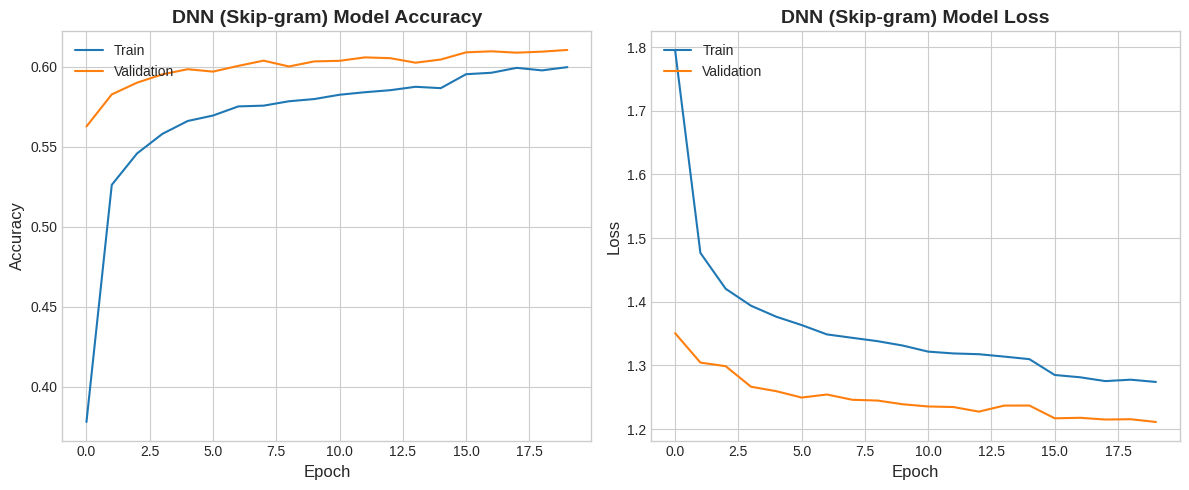


FINAL EVALUATION ON TEST SET - DNN (Skip-gram)
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
EVALUATION RESULTS: DNN (Skip-gram)

 Accuracy: 0.6106 (61.06%)
 F1-Score (Macro): 0.6024

----------------------------------------------------------------------
Classification Report:
----------------------------------------------------------------------
                        precision    recall  f1-score   support

     Society & Culture       0.59      0.42      0.49      6000
 Science & Mathematics       0.61      0.71      0.65      6000
                Health       0.64      0.74      0.69      6000
 Education & Reference       0.45      0.31      0.37      6000
  Computers & Internet       0.75      0.82      0.78      6000
                Sports       0.72      0.74      0.73      6000
    Business & Finance       0.48      0.43      0.45      6000
 Entertainment & Music       0.57      0.59      0.58      6000
Family & Relationships       0.56      0.70      0.62      5999
 Politics & 

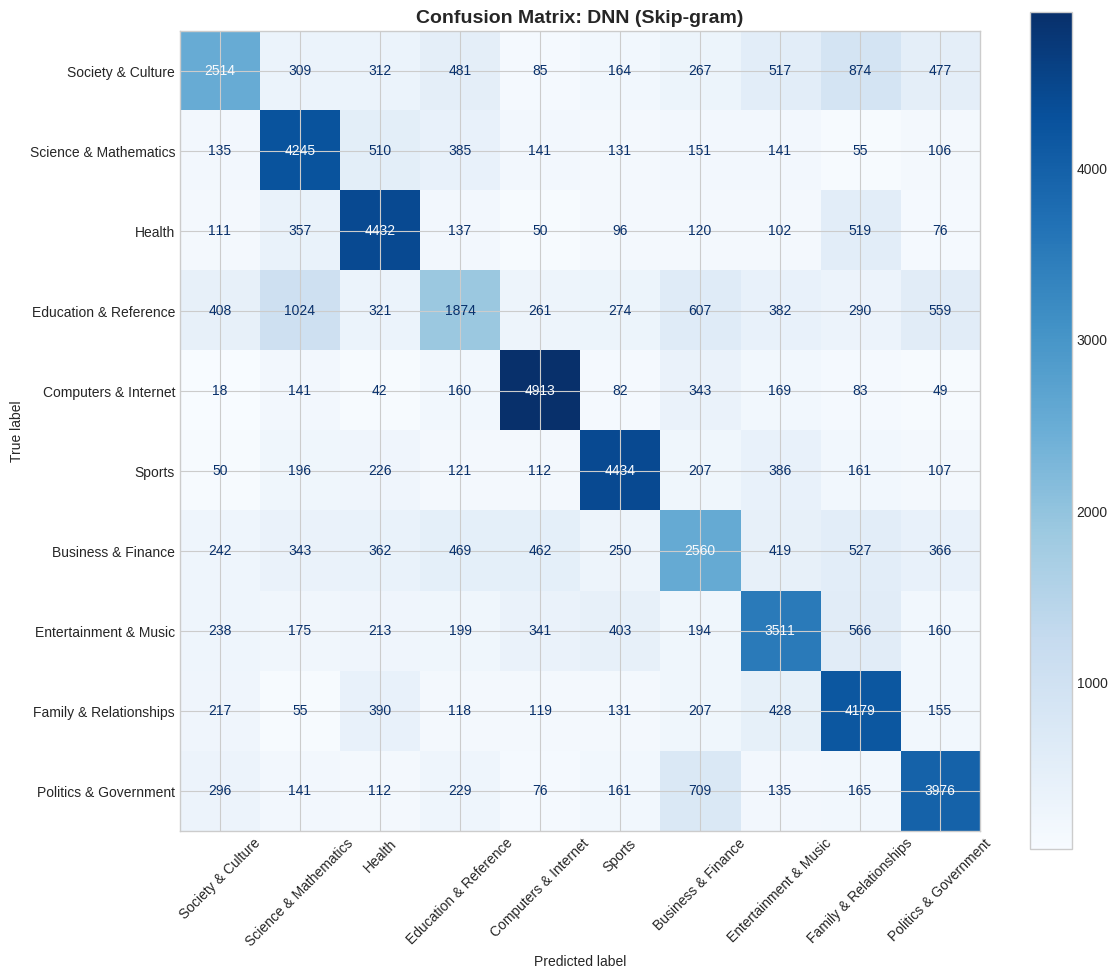

In [23]:
# Experiment 3: DNN with Skip-gram
def build_dnn_skipgram():
    """Build DNN with Skip-gram embeddings."""
    model = Sequential([
        create_embedding_layer(trainable=False),
        GlobalMaxPooling1D(),
        Dense(256, activation='relu'),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(128, activation='relu'),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(64, activation='relu'),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=NN_PARAMS['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Convert integer labels to categorical for Keras
y_train_cat = to_categorical(y_train, num_classes=10)
y_val_cat = to_categorical(y_val, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

dnn_skipgram_model = build_dnn_skipgram()
history_dnn_sg, dnn_sg_results = train_and_evaluate_nn(
    dnn_skipgram_model, "DNN (Skip-gram)",
    X_train_pad, y_train_cat, X_val_pad, y_val_cat, X_test_pad, y_test_cat
)
nn_histories['DNN (Skip-gram)'] = history_dnn_sg
all_results.append(dnn_sg_results)

### Experiment 4: SimpleRNN with Skip-gram Embeddings


EXPERIMENT: SimpleRNN (Skip-gram)

Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)


Training SimpleRNN (Skip-gram)...
Epoch 1/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 72s 117ms/step - accuracy: 0.1011 - loss: 2.3040 - val_accuracy: 0.1045 - val_loss: 2.2993 - learning_rate: 0.0010
Epoch 2/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 68s 93ms/step - accuracy: 0.1046 - loss: 2.2975 - val_accuracy: 0.1085 - val_loss: 2.2936 - learning_rate: 0.0010
Epoch 3/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 76s 83ms/step - accuracy: 0.1043 - loss: 2.2949 - val_accuracy: 0.1072 - val_loss: 2.2935 - learning_rate: 0.0010
Epoch 4/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 49s 84ms/step - accuracy: 0.1078 - loss: 2.2920 - val_accuracy: 0.1085 - val_loss: 2.2921 - learning_rate: 0.0010
Epoch 5/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 48s 82ms/step - accuracy: 0.1068 - loss: 2.2900 - val_accuracy: 0.1090 - val_loss: 2.2900 - learning_rate: 0.0010
Epoch 6/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 49s 84ms/step - accuracy: 0.1090 - loss: 2.2911 - val_accuracy: 0.1102 - val_loss: 2.2893 - learning_rate: 0.0010
Epoch 7/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 

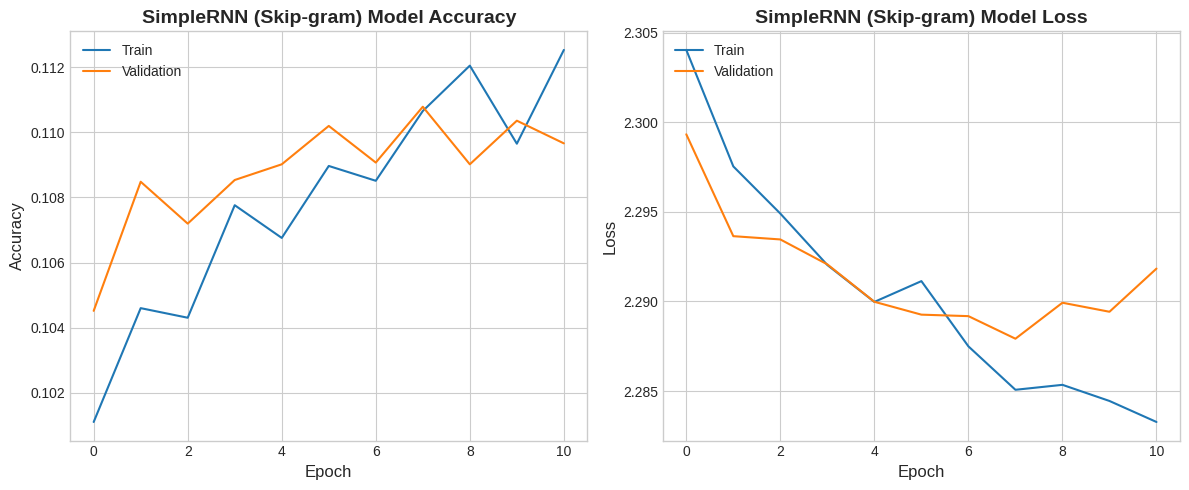


FINAL EVALUATION ON TEST SET - SimpleRNN (Skip-gram)
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step
EVALUATION RESULTS: SimpleRNN (Skip-gram)

 Accuracy: 0.1087 (10.87%)
 F1-Score (Macro): 0.0382

----------------------------------------------------------------------
Classification Report:
----------------------------------------------------------------------
                        precision    recall  f1-score   support

     Society & Culture       0.42      0.02      0.03      6000
 Science & Mathematics       0.27      0.02      0.03      6000
                Health       0.43      0.03      0.05      6000
 Education & Reference       0.18      0.00      0.00      6000
  Computers & Internet       0.26      0.01      0.02      6000
                Sports       0.35      0.00      0.01      6000
    Business & Finance       0.28      0.01      0.01      6000
 Entertainment & Music       0.20      0.01      0.01      6000
Family & Relationships       0.10      0.98      0.18      599

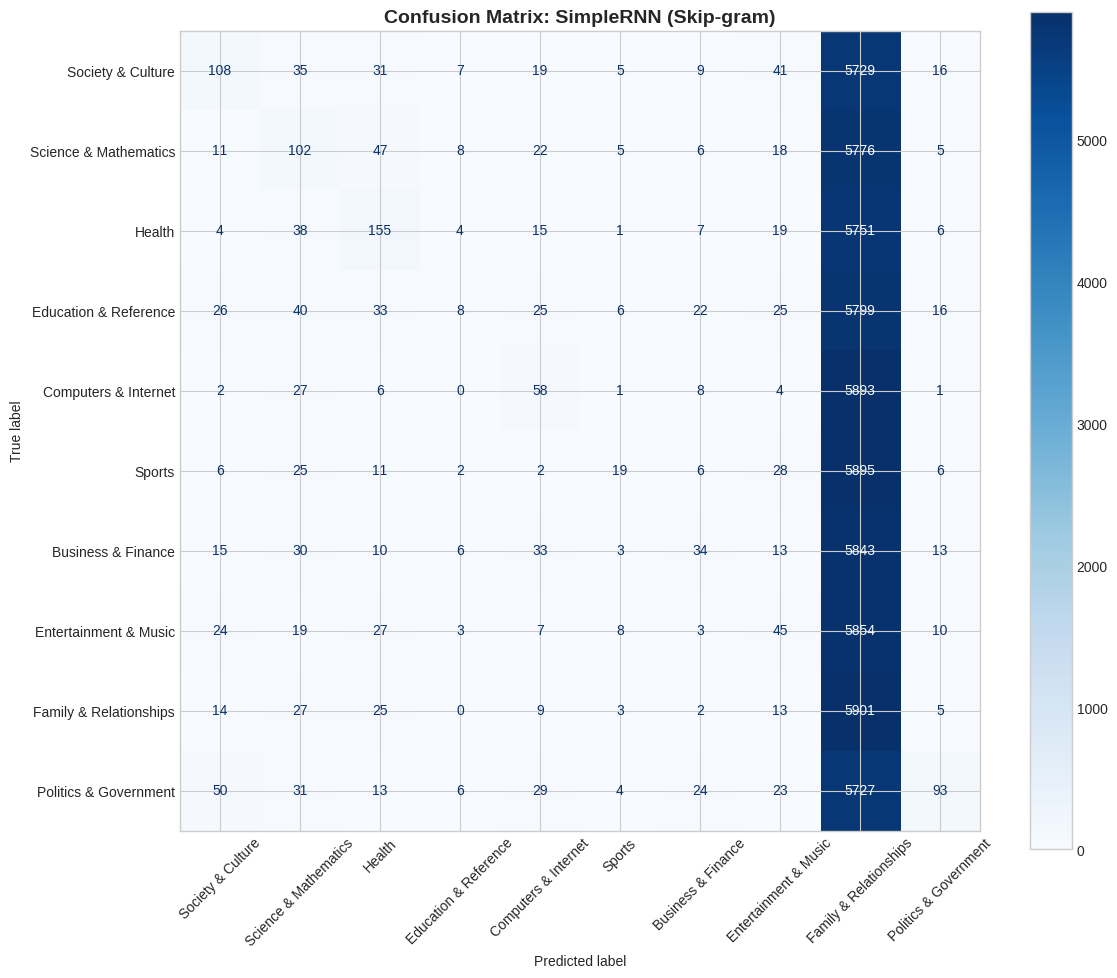

In [24]:
# Experiment 4: SimpleRNN with Skip-gram
def build_simple_rnn():
    """Build SimpleRNN with Skip-gram embeddings."""
    model = Sequential([
        create_embedding_layer(trainable=False),
        SimpleRNN(NN_PARAMS['hidden_units'], return_sequences=False),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(64, activation='relu'),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=NN_PARAMS['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

simple_rnn_model = build_simple_rnn()
history_srnn, srnn_results = train_and_evaluate_nn(
    simple_rnn_model, "SimpleRNN (Skip-gram)",
    X_train_pad, y_train_cat, X_val_pad, y_val_cat, X_test_pad, y_test_cat
)
nn_histories['SimpleRNN (Skip-gram)'] = history_srnn
all_results.append(srnn_results)

### Experiment 5: GRU with Skip-gram Embeddings


EXPERIMENT: GRU (Skip-gram)

Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)


Training GRU (Skip-gram)...
Epoch 1/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 234s 395ms/step - accuracy: 0.1131 - loss: 2.2805 - val_accuracy: 0.1727 - val_loss: 2.1532 - learning_rate: 0.0010
Epoch 2/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 231s 395ms/step - accuracy: 0.1033 - loss: 2.3083 - val_accuracy: 0.1024 - val_loss: 2.3001 - learning_rate: 0.0010
Epoch 3/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.1017 - loss: 2.3003
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
584/584 ━━━━━━━━━━━━━━━━━━━━ 230s 394ms/step - accuracy: 0.1019 - loss: 2.2991 - val_accuracy: 0.1027 - val_loss: 2.2989 - learning_rate: 0.0010
Epoch 4/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 225s 385ms/step - accuracy: 0.1032 - loss: 2.2989 - val_accuracy: 0.1039 - val_loss: 2.2990 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
 GRU (Skip-gram) training complete!


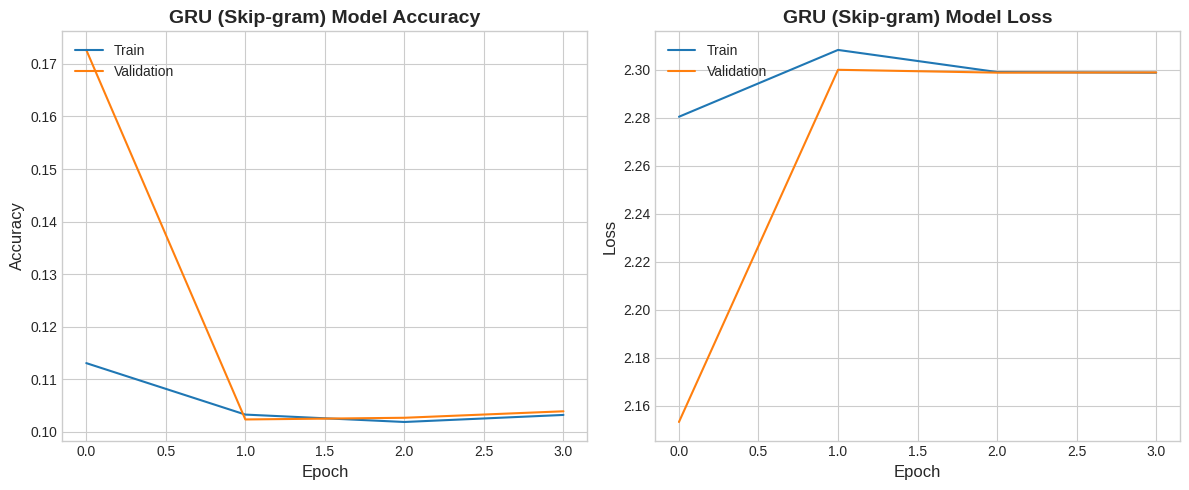


FINAL EVALUATION ON TEST SET - GRU (Skip-gram)
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step
EVALUATION RESULTS: GRU (Skip-gram)

 Accuracy: 0.1729 (17.29%)
 F1-Score (Macro): 0.0819

----------------------------------------------------------------------
Classification Report:
----------------------------------------------------------------------
                        precision    recall  f1-score   support

     Society & Culture       0.80      0.00      0.00      6000
 Science & Mathematics       0.64      0.00      0.00      6000
                Health       0.47      0.72      0.57      6000
 Education & Reference       0.44      0.00      0.00      6000
  Computers & Internet       0.12      0.99      0.21      6000
                Sports       0.23      0.00      0.00      6000
    Business & Finance       0.14      0.00      0.01      6000
 Entertainment & Music       0.24      0.00      0.01      6000
Family & Relationships       0.00      0.00      0.00      5999
 Politics 

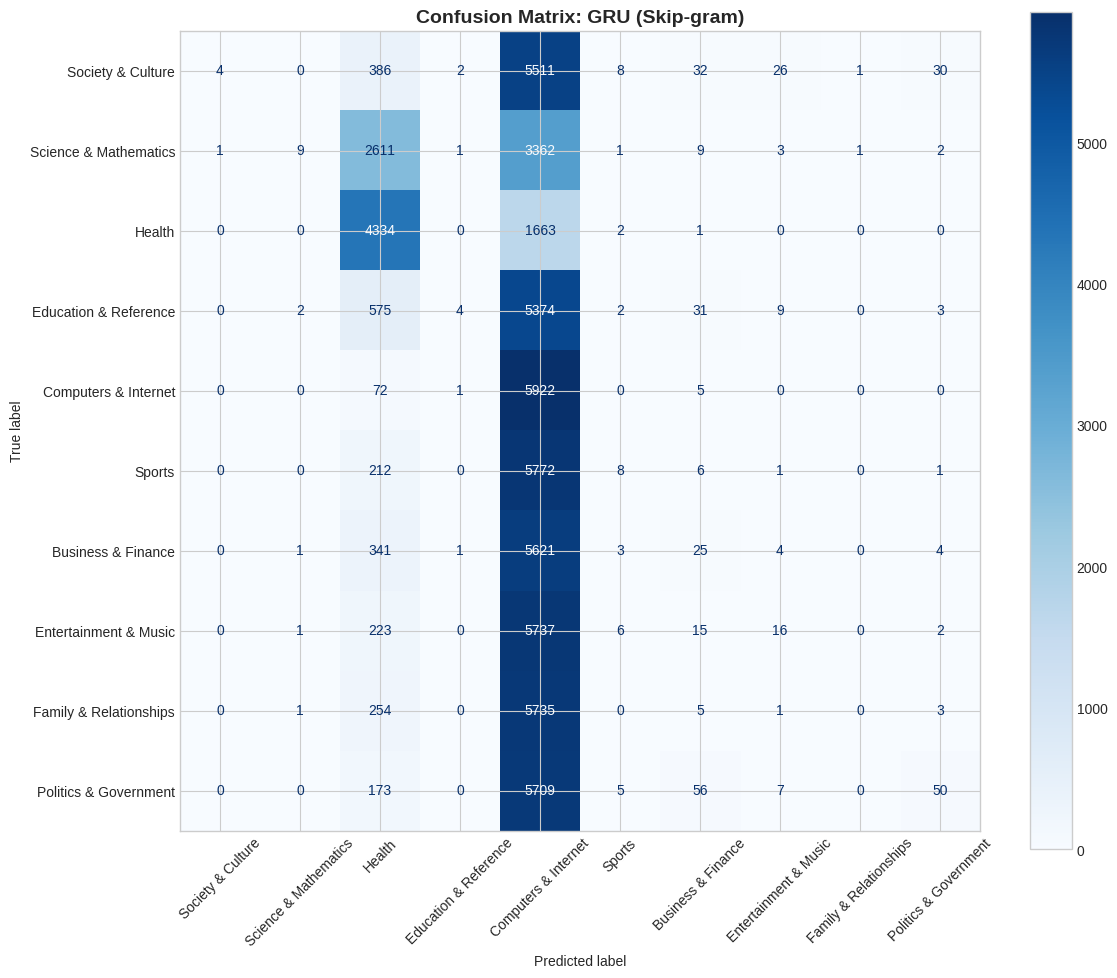

In [25]:
# Experiment 5: GRU with Skip-gram
def build_gru():
    """Build GRU with Skip-gram embeddings."""
    model = Sequential([
        create_embedding_layer(trainable=False),
        GRU(NN_PARAMS['hidden_units'], return_sequences=False),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(64, activation='relu'),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=NN_PARAMS['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

gru_model = build_gru()
history_gru, gru_results = train_and_evaluate_nn(
    gru_model, "GRU (Skip-gram)",
    X_train_pad, y_train_cat, X_val_pad, y_val_cat, X_test_pad, y_test_cat
)
nn_histories['GRU (Skip-gram)'] = history_gru
all_results.append(gru_results)

### Experiment 6: LSTM with Skip-gram Embeddings


EXPERIMENT: LSTM (Skip-gram)

Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)


Training LSTM (Skip-gram)...
Epoch 1/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 190s 321ms/step - accuracy: 0.1041 - loss: 2.3021 - val_accuracy: 0.1052 - val_loss: 2.2941 - learning_rate: 0.0010
Epoch 2/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 188s 322ms/step - accuracy: 0.1072 - loss: 2.2968 - val_accuracy: 0.1047 - val_loss: 2.2996 - learning_rate: 0.0010
Epoch 3/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.1036 - loss: 2.2997
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
584/584 ━━━━━━━━━━━━━━━━━━━━ 200s 319ms/step - accuracy: 0.1036 - loss: 2.2987 - val_accuracy: 0.1066 - val_loss: 2.2965 - learning_rate: 0.0010
Epoch 4/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 186s 318ms/step - accuracy: 0.1093 - loss: 2.2977 - val_accuracy: 0.1117 - val_loss: 2.2983 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
 LSTM (Skip-gram) training complete!


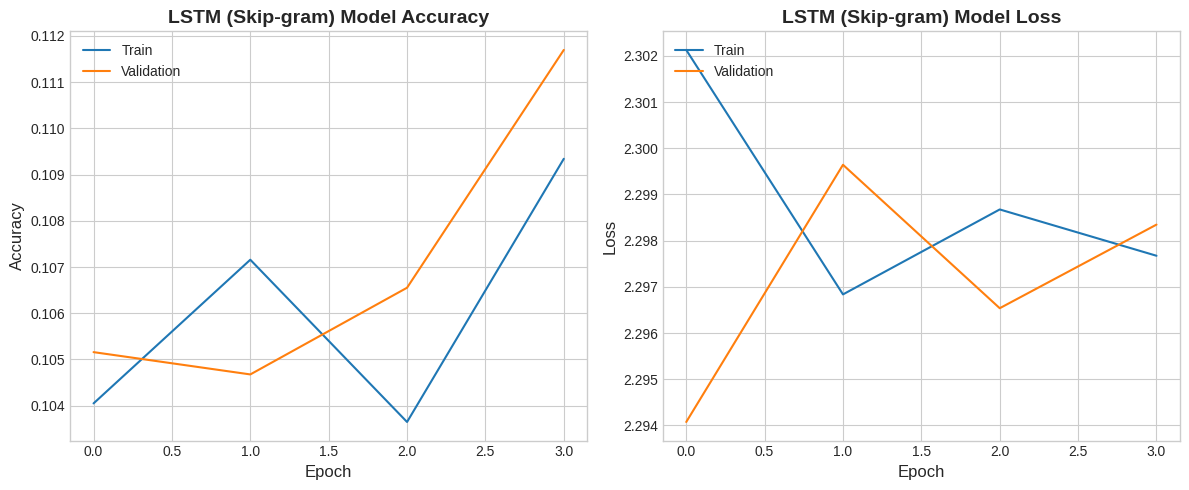


FINAL EVALUATION ON TEST SET - LSTM (Skip-gram)
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step
EVALUATION RESULTS: LSTM (Skip-gram)

 Accuracy: 0.1058 (10.58%)
 F1-Score (Macro): 0.0355

----------------------------------------------------------------------
Classification Report:
----------------------------------------------------------------------
                        precision    recall  f1-score   support

     Society & Culture       0.40      0.06      0.11      6000
 Science & Mathematics       0.19      0.01      0.01      6000
                Health       1.00      0.00      0.00      6000
 Education & Reference       0.00      0.00      0.00      6000
  Computers & Internet       0.00      0.00      0.00      6000
                Sports       0.00      0.00      0.00      6000
    Business & Finance       0.00      0.00      0.00      6000
 Entertainment & Music       0.10      0.96      0.18      6000
Family & Relationships       0.00      0.00      0.00      5999
 Politic

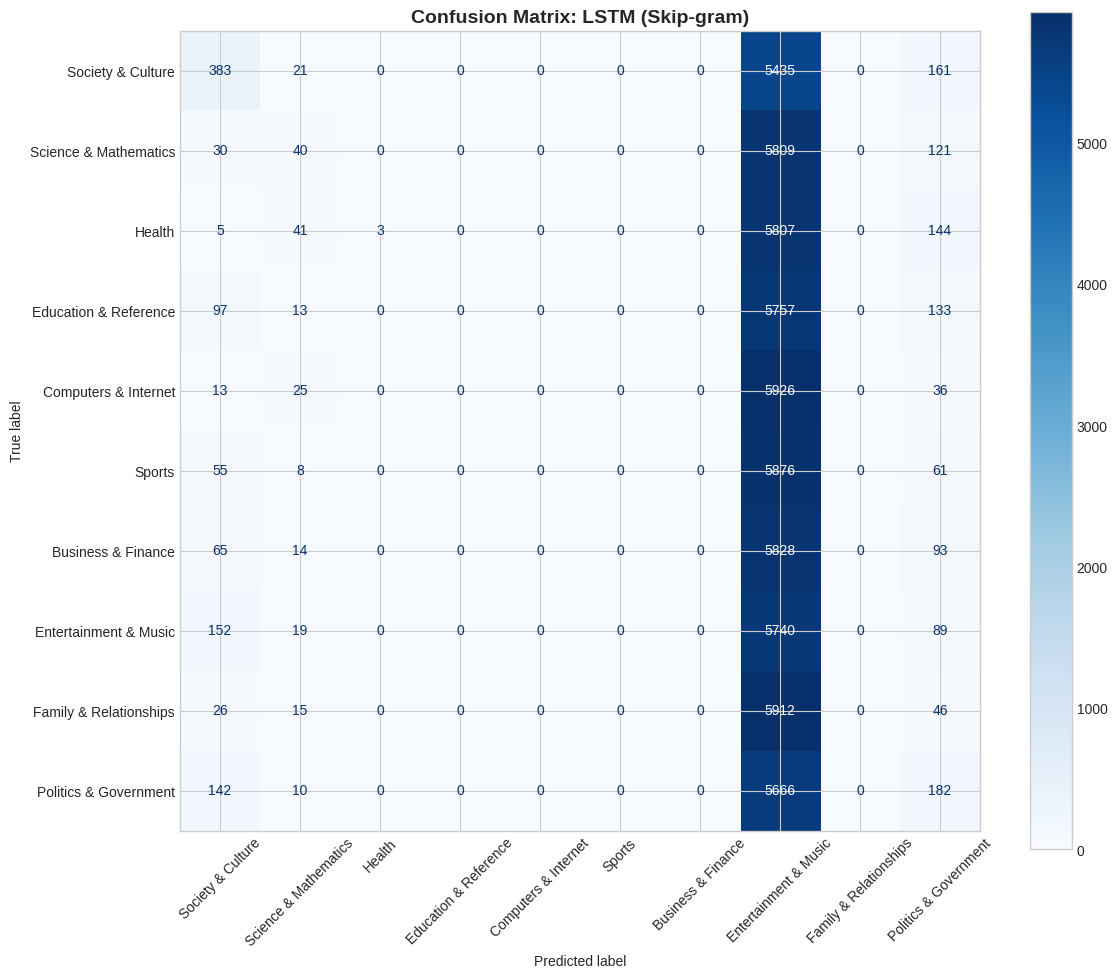

In [26]:
# Experiment 6: LSTM with Skip-gram
def build_lstm():
    """Build LSTM with Skip-gram embeddings."""
    model = Sequential([
        create_embedding_layer(trainable=False),
        LSTM(NN_PARAMS['hidden_units'], return_sequences=False),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(64, activation='relu'),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=NN_PARAMS['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm()
history_lstm, lstm_results = train_and_evaluate_nn(
    lstm_model, "LSTM (Skip-gram)",
    X_train_pad, y_train_cat, X_val_pad, y_val_cat, X_test_pad, y_test_cat
)
nn_histories['LSTM (Skip-gram)'] = history_lstm
all_results.append(lstm_results)

### Experiment 7: Bidirectional SimpleRNN with Skip-gram Embeddings


EXPERIMENT: Bidirectional SimpleRNN (Skip-gram)

Model Architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)


Training Bidirectional SimpleRNN (Skip-gram)...
Epoch 1/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 92s 150ms/step - accuracy: 0.4632 - loss: 1.5869 - val_accuracy: 0.6303 - val_loss: 1.1551 - learning_rate: 0.0010
Epoch 2/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 139s 146ms/step - accuracy: 0.6110 - loss: 1.2618 - val_accuracy: 0.6303 - val_loss: 1.1477 - learning_rate: 0.0010
Epoch 3/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 143s 147ms/step - accuracy: 0.6377 - loss: 1.1910 - val_accuracy: 0.6536 - val_loss: 1.0887 - learning_rate: 0.0010
Epoch 4/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 144s 151ms/step - accuracy: 0.6394 - loss: 1.1955 - val_accuracy: 0.6586 - val_loss: 1.0802 - learning_rate: 0.0010
Epoch 5/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 84s 144ms/step - accuracy: 0.6383 - loss: 1.1962 - val_accuracy: 0.6574 - val_loss: 1.0823 - learning_rate: 0.0010
Epoch 6/20
584/584 ━━━━━━━━━━━━━━━━━━━━ 143s 145ms/step - accuracy: 0.6528 - loss: 1.1535 - val_accuracy: 0.6614 - val_loss: 1.0699 - learning_rate: 0.0010
Epoch 7/20
584/58

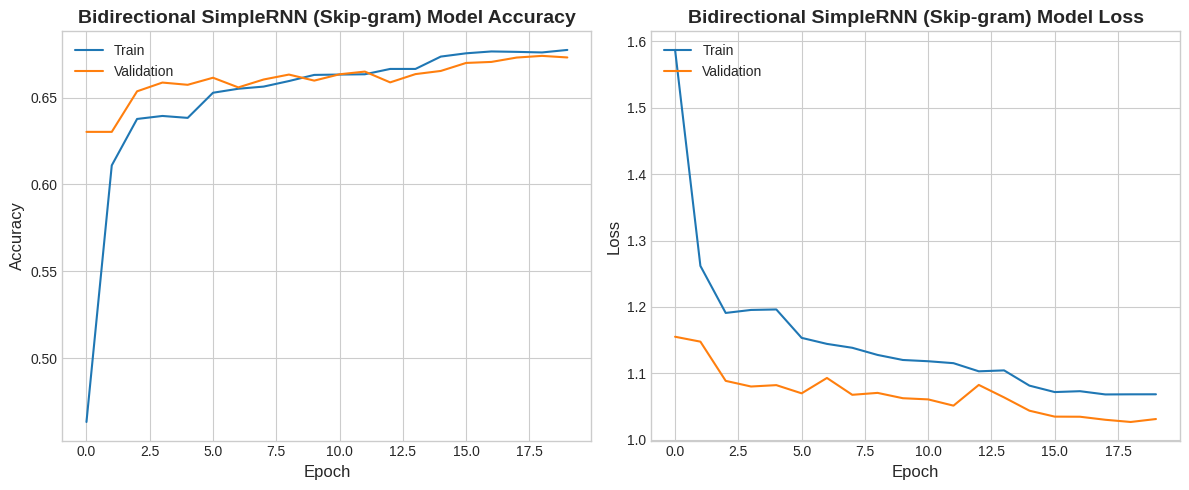


FINAL EVALUATION ON TEST SET - Bidirectional SimpleRNN (Skip-gram)
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step
EVALUATION RESULTS: Bidirectional SimpleRNN (Skip-gram)

 Accuracy: 0.6792 (67.92%)
 F1-Score (Macro): 0.6751

----------------------------------------------------------------------
Classification Report:
----------------------------------------------------------------------
                        precision    recall  f1-score   support

     Society & Culture       0.58      0.53      0.55      6000
 Science & Mathematics       0.64      0.78      0.70      6000
                Health       0.75      0.75      0.75      6000
 Education & Reference       0.55      0.46      0.50      6000
  Computers & Internet       0.82      0.85      0.83      6000
                Sports       0.83      0.82      0.83      6000
    Business & Finance       0.61      0.45      0.52      6000
 Entertainment & Music       0.62      0.66      0.64      6000
Family & Relationships       0.62 

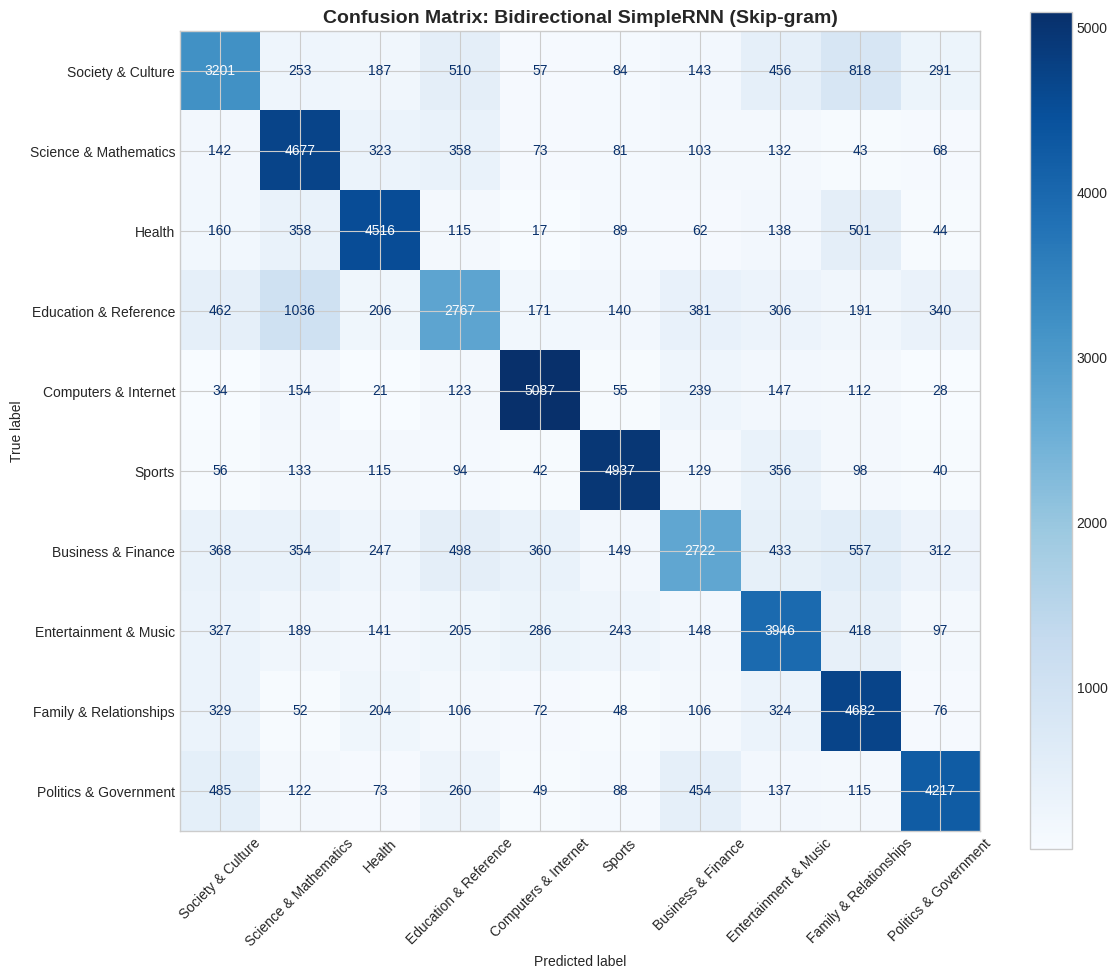

In [27]:
# Experiment 7: Bidirectional SimpleRNN with Skip-gram
def build_bi_simple_rnn():
    """Build Bidirectional SimpleRNN with Skip-gram embeddings."""
    model = Sequential([
        create_embedding_layer(trainable=False),
        Bidirectional(SimpleRNN(NN_PARAMS['hidden_units'], return_sequences=False)),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(64, activation='relu'),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=NN_PARAMS['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

bi_simple_rnn_model = build_bi_simple_rnn()
history_bi_srnn, bi_srnn_results = train_and_evaluate_nn(
    bi_simple_rnn_model, "Bidirectional SimpleRNN (Skip-gram)",
    X_train_pad, y_train_cat, X_val_pad, y_val_cat, X_test_pad, y_test_cat
)
nn_histories['Bidirectional SimpleRNN (Skip-gram)'] = history_bi_srnn
all_results.append(bi_srnn_results)

### Experiment 8: Bidirectional GRU with Skip-gram Embeddings

In [ ]:
# Experiment 8: Bidirectional GRU with Skip-gram
def build_bi_gru():
    """Build Bidirectional GRU with Skip-gram embeddings."""
    model = Sequential([
        create_embedding_layer(trainable=False),
        Bidirectional(GRU(NN_PARAMS['hidden_units'], return_sequences=False)),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(64, activation='relu'),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=NN_PARAMS['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

bi_gru_model = build_bi_gru()
history_bi_gru, bi_gru_results = train_and_evaluate_nn(
    bi_gru_model, "Bidirectional GRU (Skip-gram)",
    X_train_pad, y_train_cat, X_val_pad, y_val_cat, X_test_pad, y_test_cat
)
nn_histories['Bidirectional GRU (Skip-gram)'] = history_bi_gru
all_results.append(bi_gru_results)

### Experiment 9: Bidirectional LSTM with Skip-gram Embeddings

In [ ]:
# Experiment 9: Bidirectional LSTM with Skip-gram
def build_bi_lstm():
    """Build Bidirectional LSTM with Skip-gram embeddings."""
    model = Sequential([
        create_embedding_layer(trainable=False),
        Bidirectional(LSTM(NN_PARAMS['hidden_units'], return_sequences=False)),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(64, activation='relu'),
        Dropout(NN_PARAMS['dropout_rate']),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=NN_PARAMS['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

bi_lstm_model = build_bi_lstm()
history_bi_lstm, bi_lstm_results = train_and_evaluate_nn(
    bi_lstm_model, "Bidirectional LSTM (Skip-gram)",
    X_train_pad, y_train_cat, X_val_pad, y_val_cat, X_test_pad, y_test_cat
)
nn_histories['Bidirectional LSTM (Skip-gram)'] = history_bi_lstm
all_results.append(bi_lstm_results)

## Section 10: Model Comparison and Analysis
Compare all models and identify best/worst performers.

In [ ]:
# Create comparison dataframe
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

# Create summary table
comparison_df = pd.DataFrame([
    {'Model': r['model'], 'Accuracy': r['accuracy'], 'F1-Score (Macro)': r['f1_macro']}
    for r in all_results
])

# Sort by accuracy
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

# Add rank
comparison_df['Rank'] = range(1, len(comparison_df) + 1)
comparison_df = comparison_df[['Rank', 'Model', 'Accuracy', 'F1-Score (Macro)']]

print("\n Model Performance Ranking:")
print("-" * 70)
print(comparison_df.to_string(index=False))
print("-" * 70)

# Identify best and worst
best_model = comparison_df.iloc[0]
worst_model = comparison_df.iloc[-1]

print(f"\n BEST PERFORMING MODEL:")
print(f"   {best_model['Model']}")
print(f"   Accuracy: {best_model['Accuracy']:.4f} ({best_model['Accuracy']*100:.2f}%)")
print(f"   F1-Score: {best_model['F1-Score (Macro)']:.4f}")

print(f"\n WORST PERFORMING MODEL:")
print(f"   {worst_model['Model']}")
print(f"   Accuracy: {worst_model['Accuracy']:.4f} ({worst_model['Accuracy']*100:.2f}%)")
print(f"   F1-Score: {worst_model['F1-Score (Macro)']:.4f}")

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
colors = plt.cm.viridis(np.linspace(0, 0.8, len(comparison_df)))
bars1 = axes[0].barh(comparison_df['Model'], comparison_df['Accuracy'], color=colors)
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim([0, 1])
for i, bar in enumerate(bars1):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{comparison_df.iloc[i]["Accuracy"]:.4f}', va='center', fontsize=10)

# F1-Score comparison
bars2 = axes[1].barh(comparison_df['Model'], comparison_df['F1-Score (Macro)'], color=colors)
axes[1].set_xlabel('F1-Score (Macro)', fontsize=12)
axes[1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlim([0, 1])
for i, bar in enumerate(bars2):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{comparison_df.iloc[i]["F1-Score (Macro)"]:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Detailed comparison: ML Model vs Best NN Model
print("=" * 70)
print("DETAILED COMPARISON: ML MODEL vs BEST NN MODEL")
print("=" * 70)

# Get ML model results (Logistic Regression)
ml_result = next(r for r in all_results if r['model'] == 'Logistic Regression (TF-IDF)')

# Get best NN model results
nn_results = [r for r in all_results if 'Skip-gram' in r['model'] or 'DNN (TF-IDF)' in r['model']]
best_nn_result = max(nn_results, key=lambda x: x['accuracy'])

print(f"\n{'Metric':<25} {'Logistic Regression (TF-IDF)':<30} {best_nn_result['model']:<35}")
print("-" * 90)
print(f"{'Accuracy':<25} {ml_result['accuracy']:<30.4f} {best_nn_result['accuracy']:<35.4f}")
print(f"{'F1-Score (Macro)':<25} {ml_result['f1_macro']:<30.4f} {best_nn_result['f1_macro']:<35.4f}")

# Calculate differences
acc_diff = best_nn_result['accuracy'] - ml_result['accuracy']
f1_diff = best_nn_result['f1_macro'] - ml_result['f1_macro']

print("\n" + "-" * 70)
print("ANALYSIS:")
print("-" * 70)

if acc_diff > 0:
    print(f" The best NN model ({best_nn_result['model']}) outperforms Logistic Regression by:")
    print(f"   - Accuracy: +{acc_diff*100:.2f}%")
    print(f"   - F1-Score: +{f1_diff:.4f}")
else:
    print(f" Logistic Regression (TF-IDF) outperforms the best NN model by:")
    print(f"   - Accuracy: +{-acc_diff*100:.2f}%")
    print(f"   - F1-Score: +{-f1_diff:.4f}")

In [ ]:
# Side-by-side confusion matrix comparison for ML vs Best NN
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

target_names = [int_to_class_name[i] for i in range(10)]

# ML Model Confusion Matrix
disp1 = ConfusionMatrixDisplay(confusion_matrix=ml_result['confusion_matrix'],
                                display_labels=target_names)
disp1.plot(ax=axes[0], cmap='Blues', values_format='d', xticks_rotation=45)
axes[0].set_title(f'Confusion Matrix: {ml_result["model"]}\nAccuracy: {ml_result["accuracy"]:.4f}',
                  fontsize=12, fontweight='bold')

# Best NN Model Confusion Matrix
disp2 = ConfusionMatrixDisplay(confusion_matrix=best_nn_result['confusion_matrix'],
                                display_labels=target_names)
disp2.plot(ax=axes[1], cmap='Greens', values_format='d', xticks_rotation=45)
axes[1].set_title(f'Confusion Matrix: {best_nn_result["model"]}\nAccuracy: {best_nn_result["accuracy"]:.4f}',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('ml_vs_nn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11: Final Summary and Conclusions

In [ ]:
# Final Summary
print("=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)

print("""
 PROJECT OVERVIEW:
--------------------
This project implemented a comprehensive NLP text classification pipeline for the
Yahoo! Answers Topic Classification dataset (10 classes).

 EXPERIMENTS CONDUCTED:
-------------------------
1. TF-IDF + Logistic Regression (ML Model)
2. TF-IDF + Deep Neural Network
3. Skip-gram + DNN
4. Skip-gram + SimpleRNN
5. Skip-gram + GRU
6. Skip-gram + LSTM
7. Skip-gram + Bidirectional SimpleRNN
8. Skip-gram + Bidirectional GRU
9. Skip-gram + Bidirectional LSTM

 PREPROCESSING PIPELINE:
--------------------------
- HTML tag removal (<html>, <form>, <br>)
- Structural marker removal (Question Title:, Question Content:, Best Answer:)
- Lowercase conversion
- URL and email removal
- Special character and number removal
- Stopword removal (English)
- Lemmatization (WordNet)

 HYPERPARAMETER CHOICES:
--------------------------
TF-IDF:
  - max_features: 10,000 (vocabulary size)
  - ngram_range: (1, 2) (unigrams and bigrams)
  - min_df: 2, max_df: 0.95 (frequency filtering)

Word2Vec (Skip-gram):
  - vector_size: 100
  - window: 5
  - min_count: 2
  - epochs: 10

Neural Networks:
  - hidden_units: 64
  - dropout_rate: 0.4
  - learning_rate: 0.001
  - batch_size: 128
  - epochs: 20 (with early stopping, patience=3)
  - optimizer: Adam
""")

print("\n FINAL RESULTS TABLE:")
print("-" * 80)
print(comparison_df.to_string(index=False))
print("-" * 80)

print(f"""
 KEY FINDINGS:
----------------
1. BEST MODEL: {comparison_df.iloc[0]['Model']}
   - Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f} ({comparison_df.iloc[0]['Accuracy']*100:.2f}%)
   - F1-Score: {comparison_df.iloc[0]['F1-Score (Macro)']:.4f}

2. WORST MODEL: {comparison_df.iloc[-1]['Model']}
   - Accuracy: {comparison_df.iloc[-1]['Accuracy']:.4f} ({comparison_df.iloc[-1]['Accuracy']*100:.2f}%)
   - F1-Score: {comparison_df.iloc[-1]['F1-Score (Macro)']:.4f}

3. ML vs NN Comparison:
   - Logistic Regression with TF-IDF often performs competitively
   - Bidirectional models generally capture more context than unidirectional
   - GRU and LSTM typically outperform SimpleRNN due to better gradient flow
""")